## Student Performance Indicator

### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [5]:
df = pd.read_csv('data/StudentsPerformance.csv')

#### Show Top 5 Records

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [7]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- 3.1. Check Missing values
- 3.2. Check Duplicates
- 3.3. Check data type
- 3.4. Check the number of unique values of each column
- 3.5. Check statistics of data set
- 3.6. Check various categories present in the different categorical column
- 3.7. Adding Columns

### 3.1 Check Missing values

In [8]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [9]:
df.duplicated().sum()

0

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [10]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column

In [11]:
# get the number of unique values in each column
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check statistics of data set

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 69.2;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.6 Exploring Data (categories present in the different categorical column)

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
class EDAAnalyzer:
    def __init__(self,df:pd.DataFrame):
        self.df = df    # Store the reference to the original DataFrame
        
    def get_categorical_columns(self):
        """Return a list of column names that are categorical."""
        cat_cols = self.df.select_dtypes(include='object').columns.tolist()
        return cat_cols
    
    def get_numerical_columns(self):
        """Return a list of column names that are numerical."""
        num_cols = self.df.select_dtypes(exclude='object').columns.tolist()
        return num_cols
    
    def get_categorical_columns_unique_values(self):
        cat_col_unique_vals = dict()
        cat_cols = self.get_categorical_columns()
        for col in cat_cols:
            unique_vals = self.df[col].unique().tolist()
            cat_col_unique_vals[col] = unique_vals
        return cat_col_unique_vals

    def get_categorical_columns_unique_value_dist(self):
        cat_cols = self.get_categorical_columns()
        cat_summary = {col : list(self.df[col].value_counts().items()) for col in cat_cols}
        return cat_summary
    
    def print_cat_cols_unique_vals(self):
        cat_col_unique_vals = self.get_categorical_columns_unique_values()
        print("Categorical Columns : Unique Values in them")
        for cat in cat_col_unique_vals:
            print("Categories in ",cat," column :   ", cat_col_unique_vals[cat])
 

    def get_num_condition(self,feature:str, condition)->int:
        """
        Count number of rows where a condition on a feature is satisfied.

        Parameters:
        - feature (str): Column name
        - condition (Callable): A function/lambda applied to the column values

        Returns:
        - int: Number of rows satisfying the condition
        """
        if feature not in self.df.columns:
            raise ValueError(f"Column '{feature}' not found in DataFrame")
            
        mask = condition(self.df[feature])
        return mask.sum()


    def histplot(ax, x_col, hue=None, title=None, bins=30):
        sns.histplot(data=self.df, x=x_col, kde=True, bins=bins, hue=hue, ax=ax)
        if title:
            ax.set_title(title)

    """def plot_histograms(self, x_col:str, hue:str=None, bins:int=30, figsize=(8, 6)):
        fig, ax = plt.subplots(figsize)
        self.histplot(ax, x_col, hue, title=x_col, bins=bins)
        fig.tight_layout()
        plt.show()"""

In [15]:
eda_analysis = EDAAnalyzer(df)

In [16]:
# get categorical columns unique values:
eda_analysis.print_cat_cols_unique_vals()

Categorical Columns : Unique Values in them
Categories in  gender  column :    ['female', 'male']
Categories in  race/ethnicity  column :    ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in  parental level of education  column :    ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in  lunch  column :    ['standard', 'free/reduced']
Categories in  test preparation course  column :    ['none', 'completed']


In [17]:
# define numerical & categorical columns
categorical_features = eda_analysis.get_categorical_columns()
numerical_features = eda_analysis.get_numerical_columns()

# print the features
print('We have {} numerical features : {}'.format(len(numerical_features), numerical_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [18]:
eda_analysis.get_categorical_columns_unique_value_dist()

{'gender': [('female', 518), ('male', 482)],
 'race/ethnicity': [('group C', 319),
  ('group D', 262),
  ('group B', 190),
  ('group E', 140),
  ('group A', 89)],
 'parental level of education': [('some college', 226),
  ("associate's degree", 222),
  ('high school', 196),
  ('some high school', 179),
  ("bachelor's degree", 118),
  ("master's degree", 59)],
 'lunch': [('standard', 645), ('free/reduced', 355)],
 'test preparation course': [('none', 642), ('completed', 358)]}

### 3.7 Adding columns for "Total Score" and "Average"

In [19]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [20]:
# Numerical features : test scores : condition - full score(100)
reading_full = eda_analysis.get_num_condition('reading score',lambda x:x==100)
writing_full = eda_analysis.get_num_condition('writing score',lambda x:x==100)
math_full = eda_analysis.get_num_condition('math score',lambda x:x==100)


# print the nums
print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [21]:
# Numerical features : test scores : condition - (<=20)
reading_less_20 = eda_analysis.get_num_condition('reading score', lambda x:x<=20)
writing_less_20 = eda_analysis.get_num_condition('writing score', lambda x:x<=20)
math_less_20 = eda_analysis.get_num_condition('math score', lambda x:x<=20)

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

In [22]:
class eda_visual:
    def __init__(self,df:pd.DataFrame):
        self.df = df

    def plot_histograms(self, column:str, hue=None,bins:int=30, figsize:tuple=(15, 7)):
        """
        Plot histogram and grouped histogram side-by-side.
        """
    
        fig, axs = plt.subplots(1, 2, figsize=figsize)
    
        # Plain histogram
        sns.histplot(data=self.df, x=column, bins=bins, kde=True, ax=axs[0])
        axs[0].set_title(f"Distribution of {column}")
    
        # Grouped histogram (if hue exists)
        if hue:
            sns.histplot(data=self.df, x=column, kde=True, hue=hue, ax=axs[1])
            axs[1].set_title(f"{column} by {hue}")
        else:
            axs[1].axis("off")
    
        plt.tight_layout()
        plt.show()


    def plot_grouped_histograms(self, x_col:str, split_col:str, hue_col:str=None, figsize=(25, 6)):
        """
        Plot histograms for full data and for each group in split_col.
        """
    
        groups = df[split_col].unique()
        n_plots = len(groups) + 1
    
        fig, axs = plt.subplots(1, n_plots, figsize=figsize)
    
        # Plot 1: full dataset
        sns.histplot(data=self.df, x=x_col, kde=True, hue=hue_col, ax=axs[0])
        axs[0].set_title(f"{x_col} (All data) wrt {hue_col}")
    
        # Grouped plots
        for i, group in enumerate(groups, start=1):
            sns.histplot(data=self.df[df[split_col] == group], x=x_col, kde=True, hue=hue_col, ax=axs[i])
            axs[i].set_title(f"{x_col} | ({split_col} = {group}) wrt {hue_col}")
    
        fig.tight_layout()
        plt.show()

    def plot_n_violinplot(self, num_sub_plots:int,column:list[str], bins:int=30, figsize:tuple=(18,8)):  
        """violinplot for any number"""
        fig, axs = plt.subplots(1, num_sub_plots, figsize=figsize)
    
        # get a list of colors of len num_sub_plots
        colors = sns.color_palette("Set1", num_sub_plots) 
    
        # plot violinplot
        for i in range(len(axs)):
            sns.violinplot(y=column[i], data=df, color=colors[i], linewidth=3, ax=axs[i])
            axs[i].set_title(f"Distribution of {column[i]}")
    
        plt.tight_layout()
        plt.show()

#### 4.1.1 Histogram & KDE

In [23]:
# eda visualizaiton object
visualization = eda_visual(df)

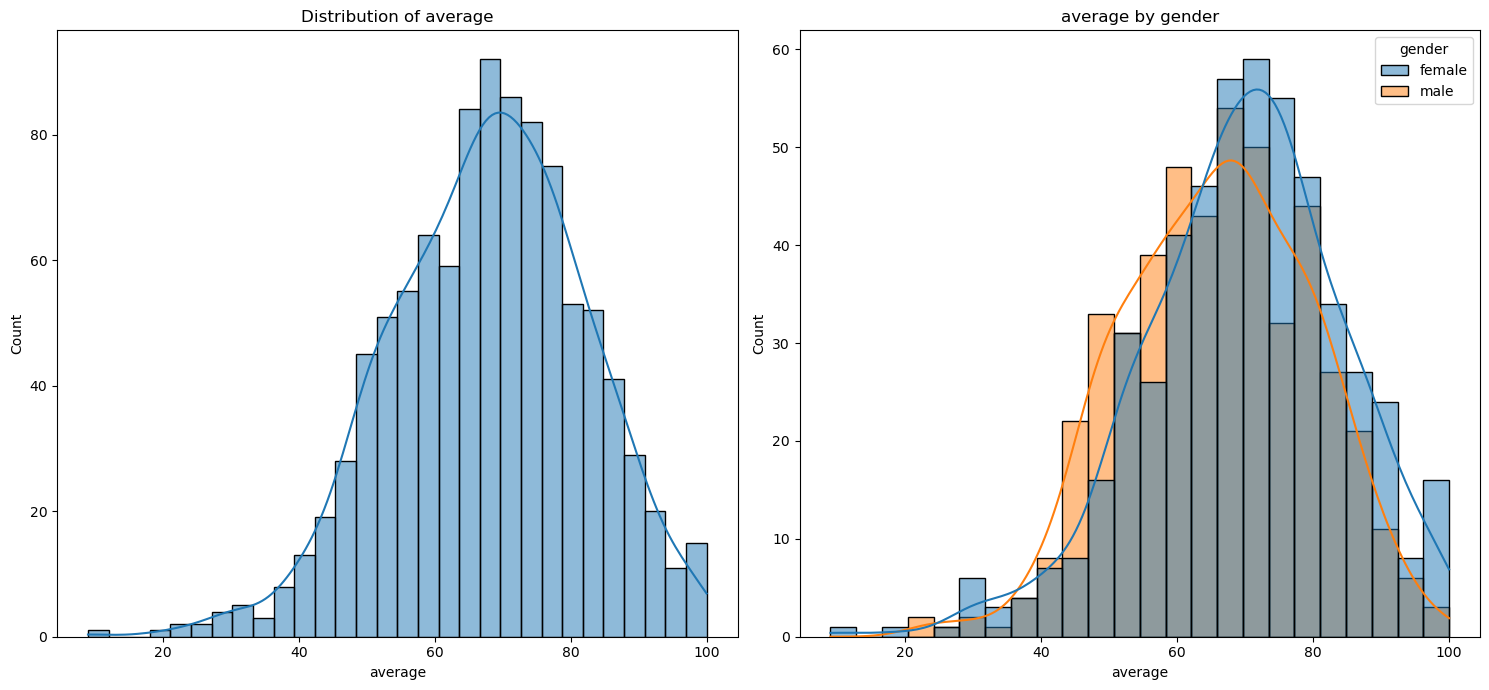

In [24]:
# plot of average distribution, average by gender distribution
visualization.plot_histograms(column='average',hue='gender')

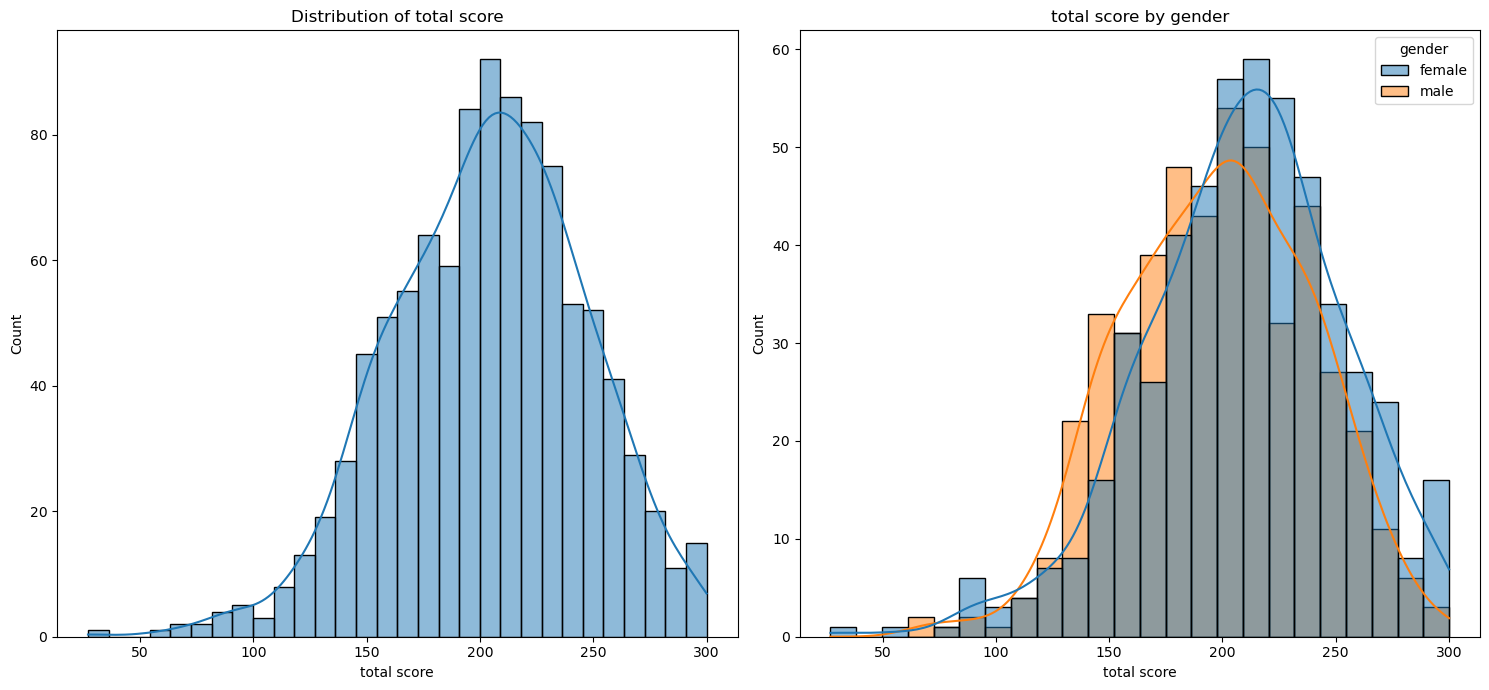

In [25]:
# plot of total score distribution, total score by gender distribution
visualization.plot_histograms(column='total score',hue='gender')

#####  Insights
- Female students tend to perform well then male students.

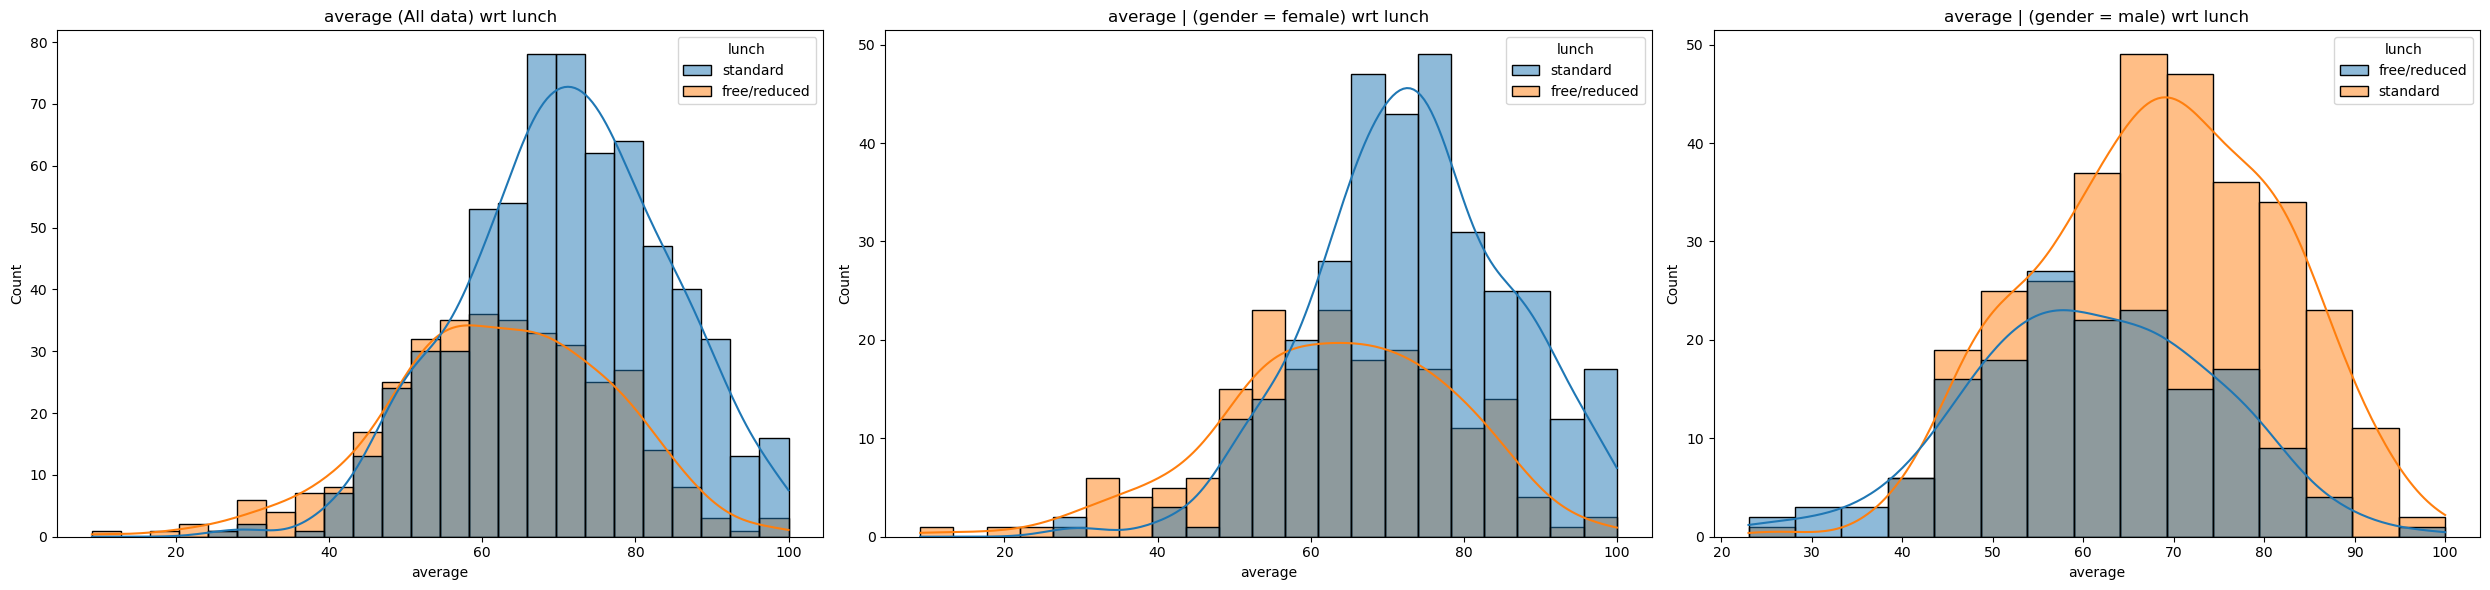

In [26]:
# 1. plot of average distribution wrt lunch
# 2. plot of female students average distribution wrt lunch
# 3. plot of male students average distribution wrt lunch

visualization.plot_grouped_histograms(x_col='average',split_col='gender',hue_col='lunch')

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

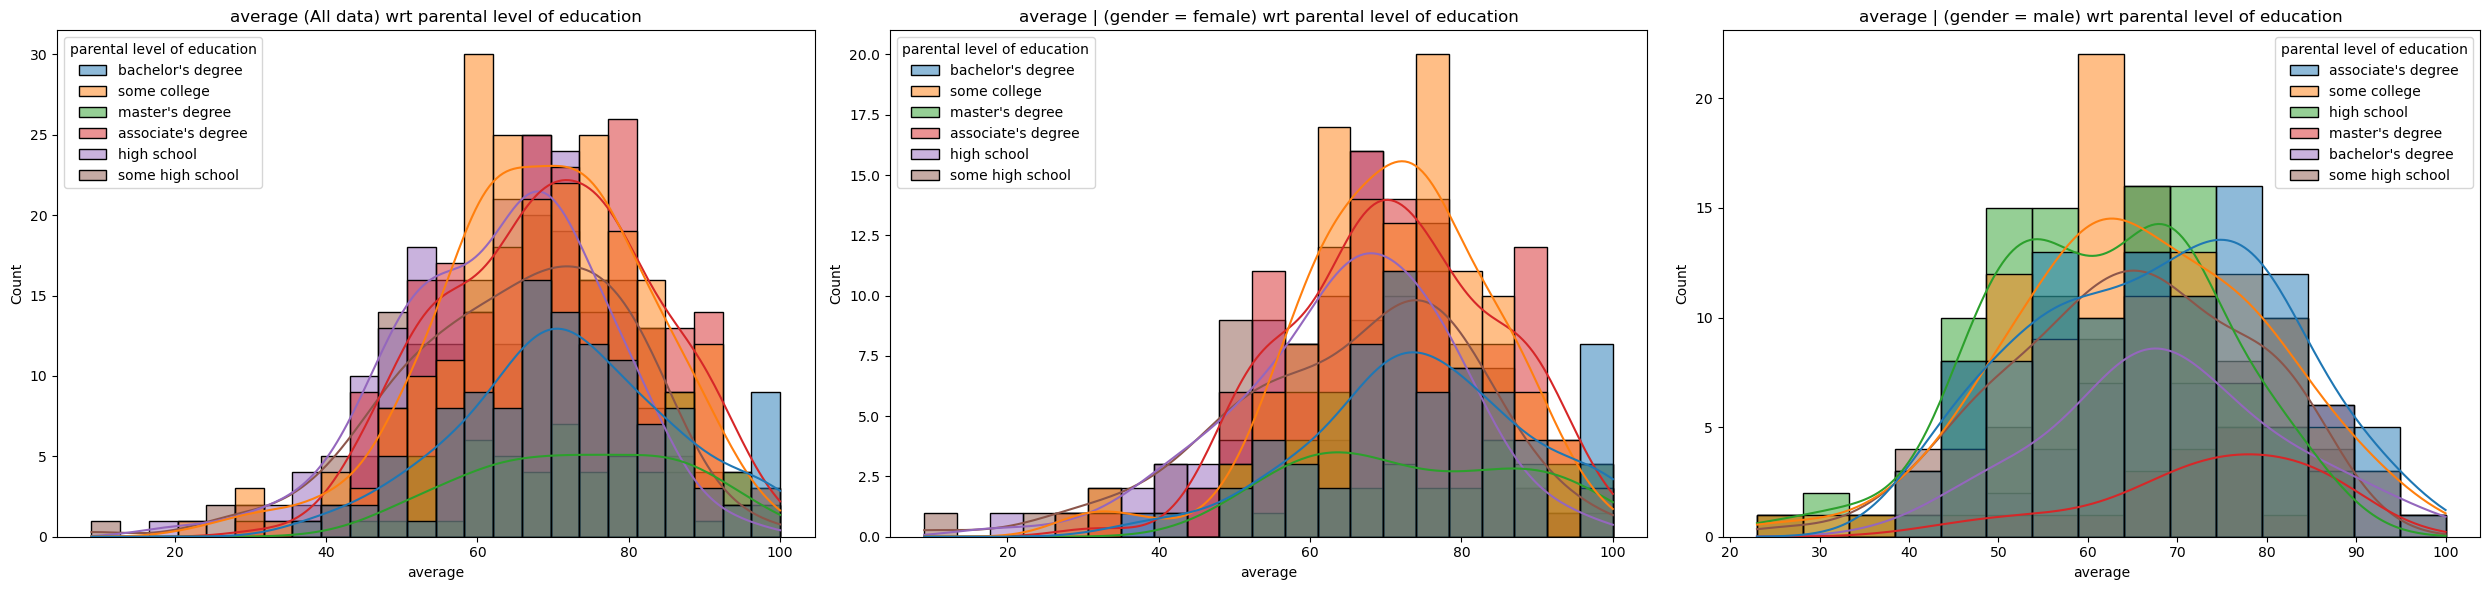

In [27]:
# 1. plot of average distribution wrt parental level of education
# 2. plot of female students average distribution wrt parental level of education
# 3. plot of male students average distribution wrt parental level of education

visualization.plot_grouped_histograms(x_col='average',split_col='gender',hue_col='parental level of education')

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

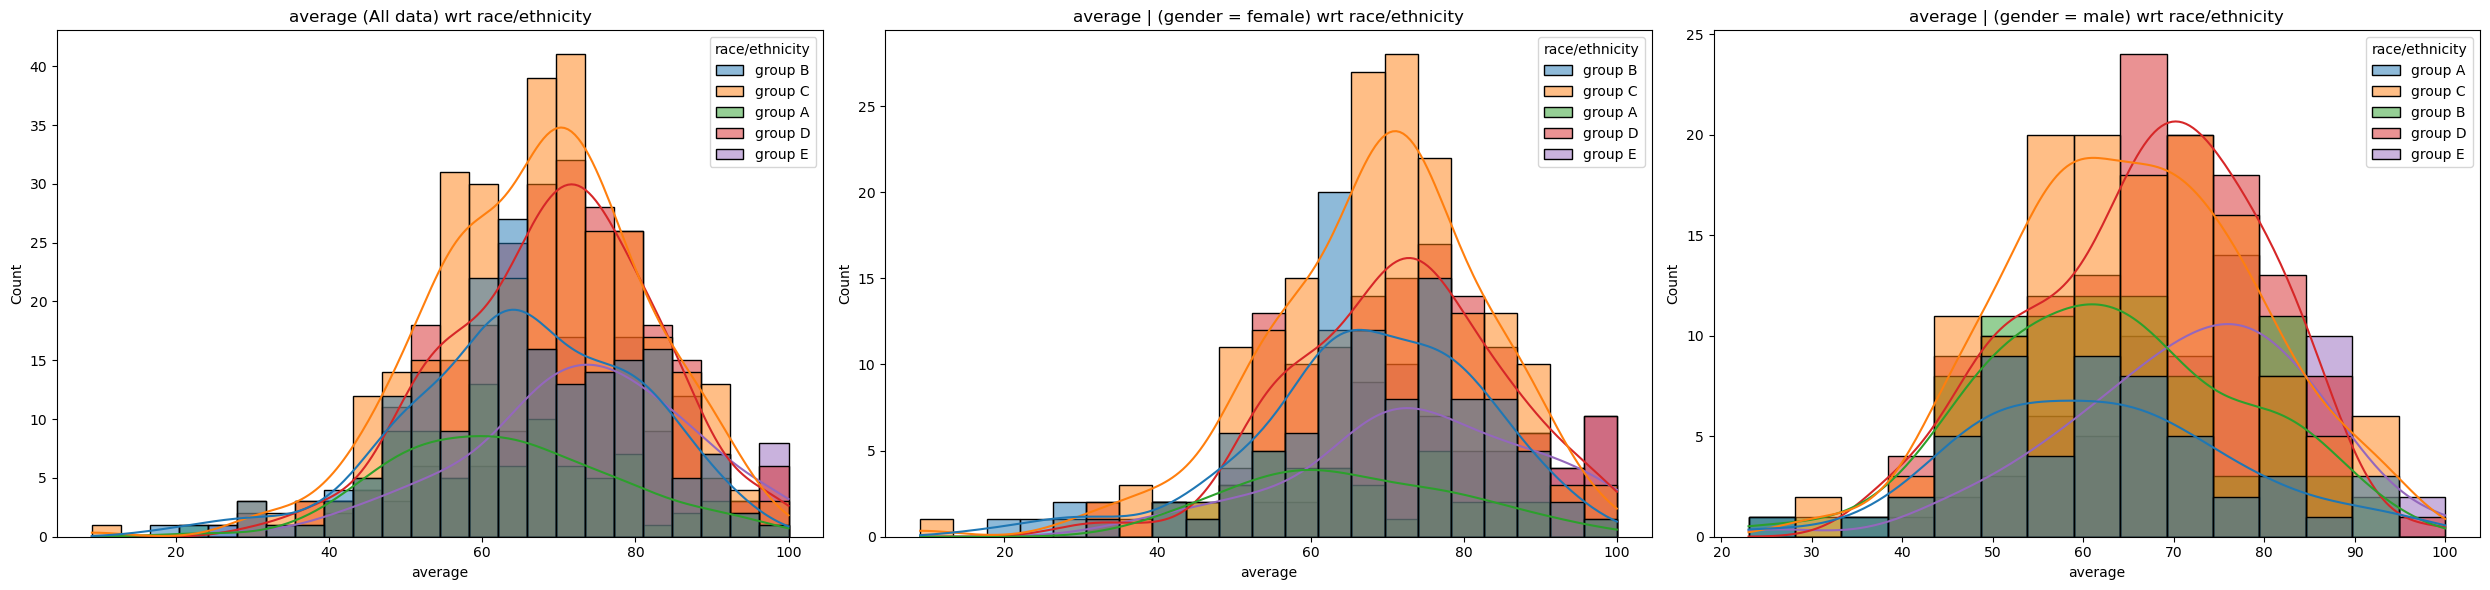

In [28]:
# 1. plot of average distribution wrt race/ethnicity
# 2. plot of female students average distribution wrt race/ethnicity
# 3. plot of male students average distribution wrt race/ethnicity

visualization.plot_grouped_histograms(x_col='average',split_col='gender',hue_col='race/ethnicity')

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximumum score of students in all three subjects

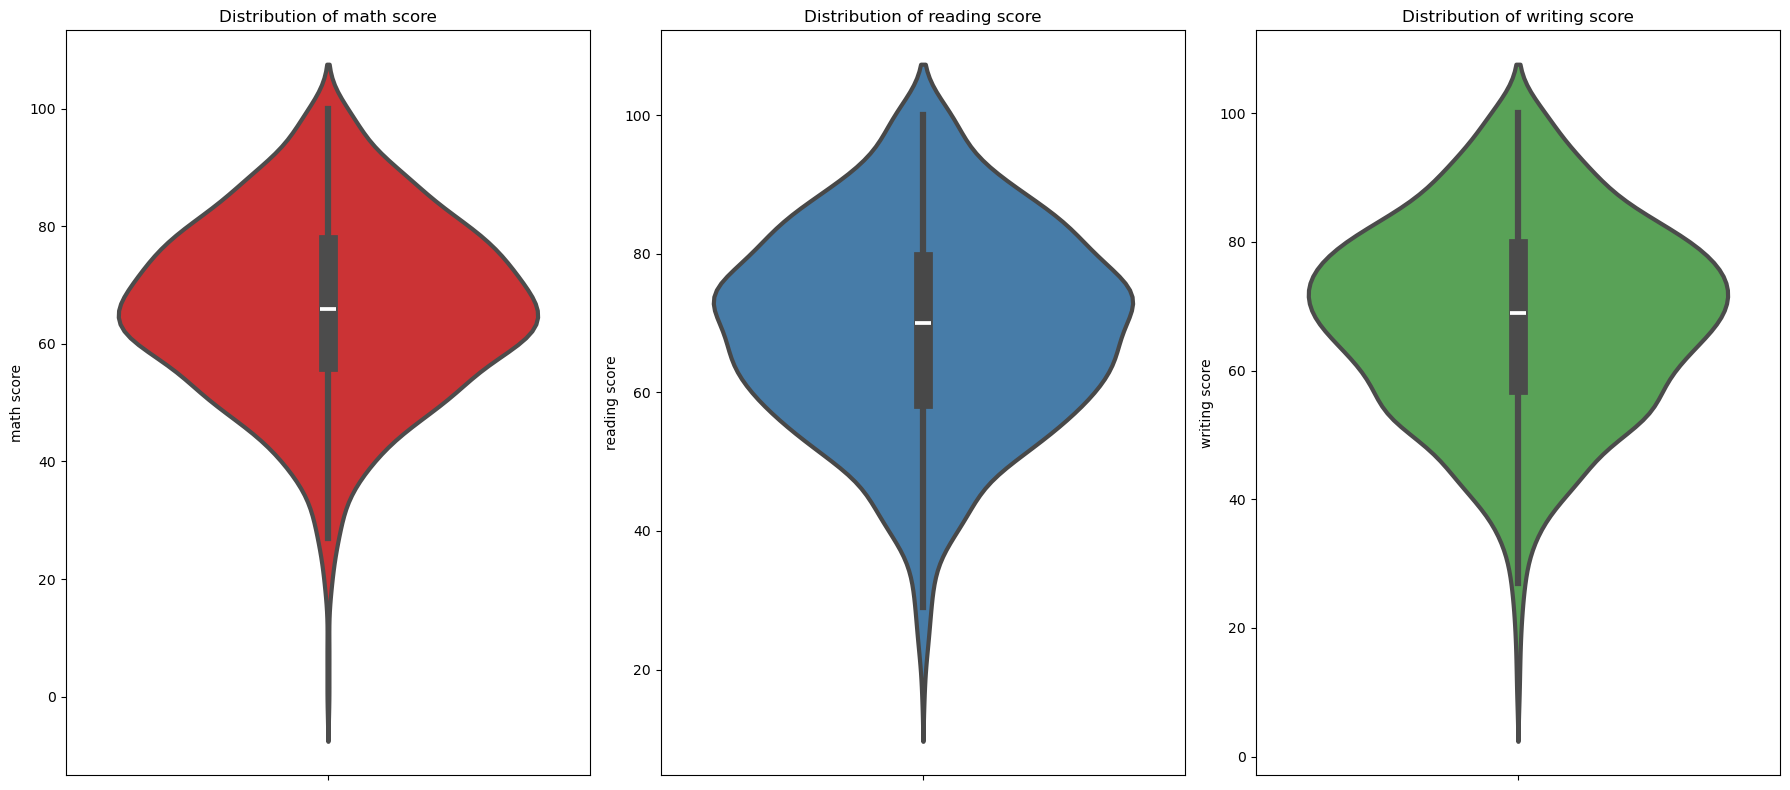

In [29]:
visualization.plot_n_violinplot(num_sub_plots=3,column=['math score', 'reading score', 'writing score'])

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate analysis using pieplot

In [89]:
def plot_pie(ax, pie_data:np.ndarray, labels:list[str], title:str, 
             label_fontsize: int = 14, title_fontsize:int=14, pct_fontsize: int = 13, 
             pctdistance:float=0.65, labeldistance:float=1.1, autopct:str='%.1f%%', 
             color_palette_set:str="Set1", explode:list[int]=None, shadow:bool=False):
    
    colors = sns.color_palette(color_palette_set, len(labels))
    
    ax.pie(pie_data, labels=labels, colors=colors, autopct=autopct, 
           pctdistance=pctdistance, labeldistance=labeldistance, textprops={'fontsize': label_fontsize},
          explode=explode, shadow=shadow)

    # Enlarge label texts explicitly
    for text in ax.texts:
        text.set_fontsize(label_fontsize)
        
    ax.set_title(title, fontsize=title_fontsize)
    ax.axis('off')

In [90]:
def plot_features_pie(data:pd.DataFrame,feature_list:list[str],figsize:tuple=(30,12)):
    # set up figure and axis
    num_pie_charts = len(feature_list)
    NCOLS_FIG = 1
    fig, axs = plt.subplots(nrows=num_pie_charts, ncols=NCOLS_FIG, figsize=figsize)

    # Normalize axs to a list
    if len(feature_list) == 1:
        axs = [axs]
         
    for ax,col in zip(axs, feature_list):
        feature_pie_data = data[col].value_counts()
        labels = feature_pie_data.index.tolist()  # index of the feature_pie_data series
        plot_pie(ax=ax, pie_data=feature_pie_data.values, labels=labels, title=col, label_fontsize=9, pct_fontsize=9)

In [91]:
cat_cols = eda_analysis.get_categorical_columns()

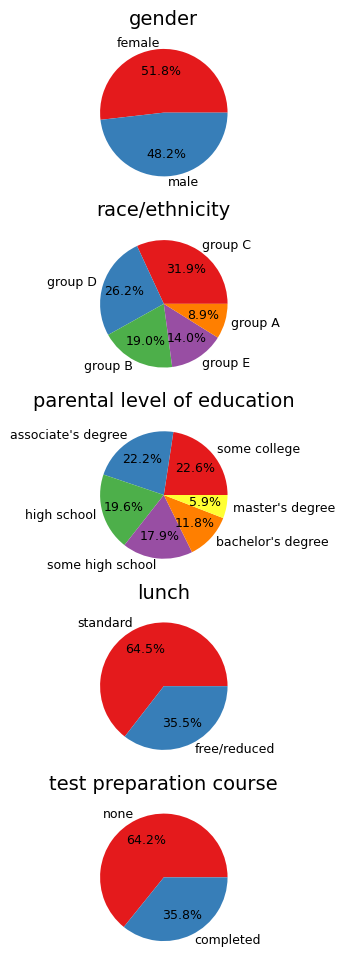

In [92]:
plot_features_pie(data=df,feature_list=cat_cols, figsize=(30,12))

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

In [238]:
def plot_count(ax, data: pd.DataFrame, feature: str, 
               tick_fontsize: int = 14,bar_label_fontsize: int = 14):
    sns.countplot(x=feature,data=data,palette='bright',ax=ax,saturation=0.95)
    
    # Tick labels
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Bar labels
    for container in ax.containers:
        ax.bar_label(container, color='black', fontsize=bar_label_fontsize)

In [239]:
# univariate analysis
def univariate_analysis(data:pd.DataFrame,feature:str, figsize=(10,6)):
    """
    feature = 'gender'
    labels = ['female','male']
    pie_data = df['gender'].value_counts() = no. of itemns in each gender class
    """
    # gives countplot and pie plot
    f,ax=plt.subplots(1,2,figsize=figsize)
    # count plot
    plot_count(ax=ax[0],data=df,feature=feature)
    
    # pie plot
    pie_data = data[feature].value_counts()
    labels = pie_data.index.tolist()
    explode = [0] + [0.1 for _ in range(len((labels)) - 1)]
    plot_pie(ax=ax[1],pie_data=pie_data.values, labels=labels, title=feature, 
             explode=explode,autopct='%1.1f%%',shadow=True)

    plt.tight_layout()
    plt.show()

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

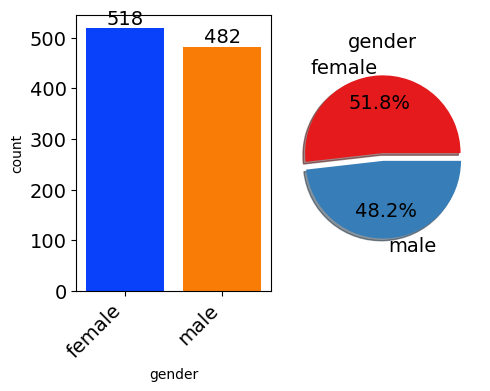

In [240]:
univariate_analysis(df,'gender',figsize=(5,4))

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [246]:
bivariate_feats = ['average','math score']

In [262]:
def bivariate_analysis_cat_cols(data:pd.DataFrame,feature:str,bivariate_features:list[str],
                                figsize:tuple=(5,3), color_palette:str="Set1",bar_estimator='mean',
                               title_size:int=9,bar_width=1):
    """
    feature = 'gender'
    bivariate_features = ['average', 'math score']
    """
    num_subplots = len(bivariate_features)
    fig, ax = plt.subplots(1,num_subplots,figsize=figsize)

    for ax,y_feature in zip(ax,bivariate_features):
        sns.barplot(data=df,x=feature,y=y_feature,palette=color_palette,
                    estimator=bar_estimator,ax=ax,width=bar_width,errorbar=None)
        # print the bar value
        for container in ax.containers:
            ax.bar_label(container,color='black',size=9)
        ax.set_title(f"{feature} vs {y_feature} {bar_estimator}",size=title_size)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

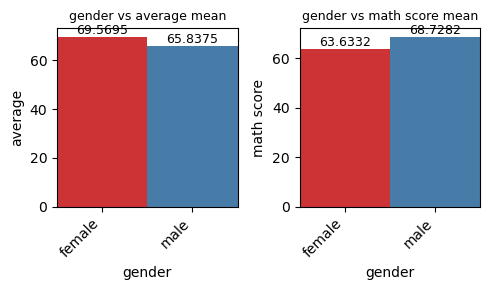

In [263]:
bivariate_analysis_cat_cols(df,feature='gender',bivariate_features=bivariate_feats)


#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

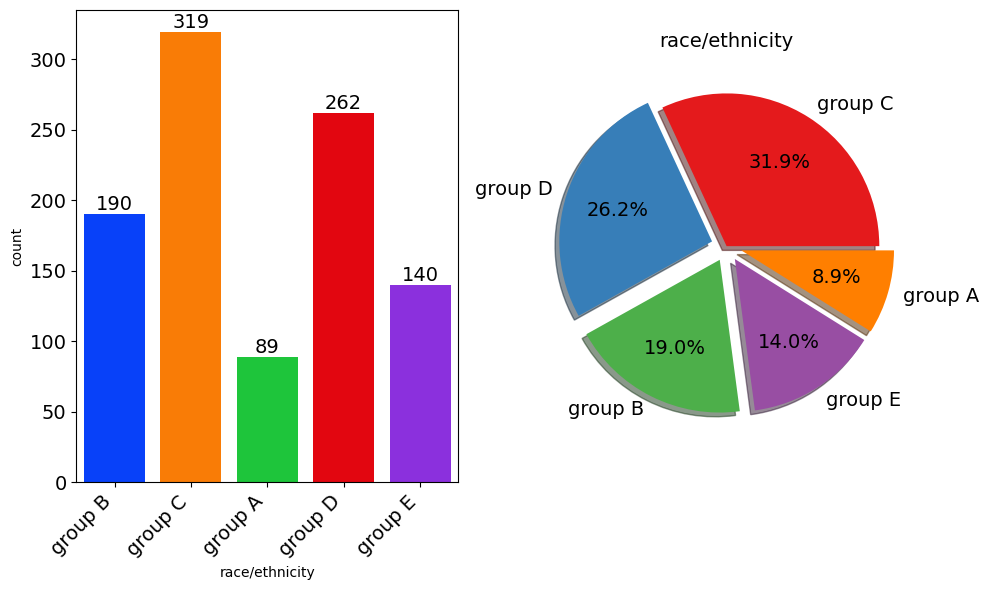

In [243]:
univariate_analysis(df,feature='race/ethnicity')

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

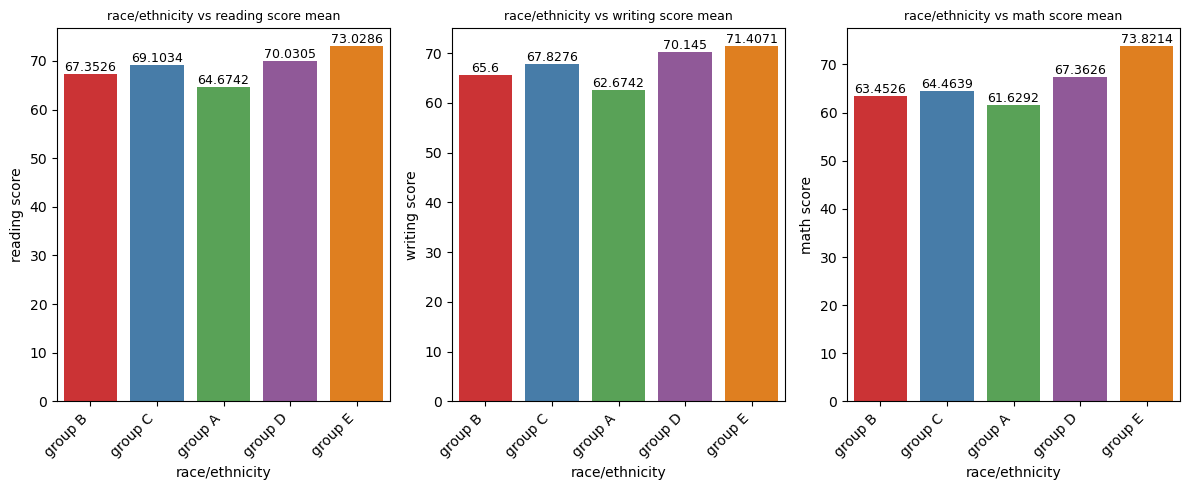

In [264]:
bivariate_analysis_cat_cols(data=df,feature='race/ethnicity',
                            bivariate_features=['reading score','writing score','math score'],
                            figsize=(12,5), bar_width=0.8)

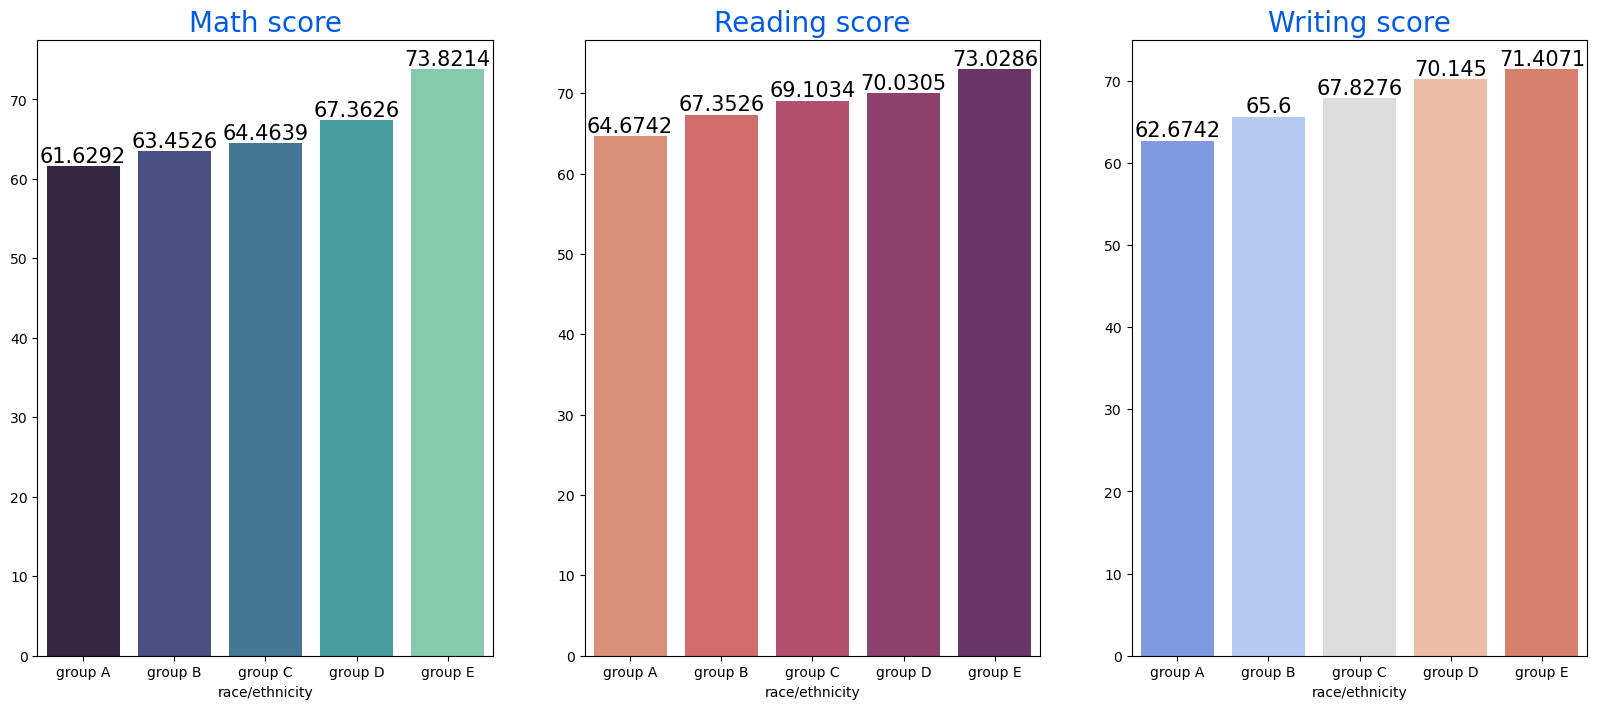

In [253]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

In [266]:
df.groupby('race/ethnicity')['math score'].mean().sort_values(ascending=True).index

Index(['group A', 'group B', 'group C', 'group D', 'group E'], dtype='object', name='race/ethnicity')

In [271]:
df.groupby('race/ethnicity').head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,232,77.333333
6,female,group B,some college,standard,completed,88,95,92,275,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,122,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.000000
10,male,group C,associate's degree,standard,none,58,54,52,164,54.666667
